# Brain Stroke CT — DataLoaders

This notebook builds and verifies DataLoaders for:
- **Classification** — 3 classes: Bleeding / Ischemia / Normal
- **Segmentation** — binary lesion mask from OVERLAY alpha channel

Outputs reusable `Dataset` classes and verified `DataLoader` objects ready for training.

## 0. Imports & Config

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from collections import Counter

import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ── Paths ──────────────────────────────────────────────────────────────────
ROOT      = Path(r'C:/Users/Beddad/Desktop/Brain_Scan/Brain_Stroke_CT_Dataset')
SAVE_DIR  = ROOT.parent

# ── Config ─────────────────────────────────────────────────────────────────
IMG_SIZE   = 256          # resize all images to 256×256
BATCH_SIZE = 16
NUM_WORKERS = 0           # set to 4+ if not on Windows or if using spawn
RANDOM_SEED = 42
VAL_RATIO   = 0.15
TEST_RATIO  = 0.10

CLASS_NAMES  = ['Bleeding', 'Ischemia', 'Normal']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('Config OK')
print(f'  IMG_SIZE={IMG_SIZE}, BATCH_SIZE={BATCH_SIZE}, SEED={RANDOM_SEED}')
print(f'  CLASS_TO_IDX: {CLASS_TO_IDX}')

Config OK
  IMG_SIZE=256, BATCH_SIZE=16, SEED=42
  CLASS_TO_IDX: {'Bleeding': 0, 'Ischemia': 1, 'Normal': 2}


## 1. Build File Lists & Train / Val / Test Splits

In [2]:
def collect_samples(classes, root):
    """Return list of (png_path, overlay_path_or_None, label) for all samples."""
    samples = []
    for cls in classes:
        png_dir = root / cls / 'PNG'
        ovl_dir = root / cls / 'OVERLAY'
        for png_path in sorted(png_dir.iterdir()):
            ovl_path = ovl_dir / png_path.name if ovl_dir.exists() else None
            if ovl_path and not ovl_path.exists():
                ovl_path = None
            samples.append((png_path, ovl_path, CLASS_TO_IDX[cls]))
    return samples

all_samples = collect_samples(CLASS_NAMES, ROOT)

# Stratified split: train / val / test
paths_list  = [s[0] for s in all_samples]
overlays    = [s[1] for s in all_samples]
labels      = [s[2] for s in all_samples]

# First split off test
idx = list(range(len(all_samples)))
train_val_idx, test_idx = train_test_split(
    idx, test_size=TEST_RATIO, stratify=labels, random_state=RANDOM_SEED)

# Then split train/val from remaining
tv_labels = [labels[i] for i in train_val_idx]
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=VAL_RATIO / (1 - TEST_RATIO),
    stratify=tv_labels, random_state=RANDOM_SEED)

def idx_to_samples(idx_list):
    return [(paths_list[i], overlays[i], labels[i]) for i in idx_list]

train_samples = idx_to_samples(train_idx)
val_samples   = idx_to_samples(val_idx)
test_samples  = idx_to_samples(test_idx)

print(f'Total samples : {len(all_samples):,}')
print(f'Train         : {len(train_samples):,}')
print(f'Val           : {len(val_samples):,}')
print(f'Test (internal): {len(test_samples):,}')
print()

# Verify class distribution in each split
for split_name, split in [('Train', train_samples), ('Val', val_samples), ('Test', test_samples)]:
    cnt = Counter(s[2] for s in split)
    line = ', '.join(f'{IDX_TO_CLASS[k]}: {v}' for k, v in sorted(cnt.items()))
    print(f'{split_name}: {line}')

Total samples : 6,650
Train         : 4,987
Val           : 998
Test (internal): 665

Train: Bleeding: 820, Ischemia: 847, Normal: 3320
Val: Bleeding: 164, Ischemia: 170, Normal: 664
Test: Bleeding: 109, Ischemia: 113, Normal: 443


## 2. External Test Set

In [3]:
ext_dir   = ROOT / "External_Test"
ext_png   = sorted((ext_dir / "PNG").iterdir())
ext_masks = sorted((ext_dir / "MASKS").iterdir())

# Pair png with mask by filename
ext_mask_dict = {p.name: p for p in ext_masks}
ext_samples = [
    (png, ext_mask_dict.get(png.name, None))
    for png in ext_png
]

# Load binary labels from labels.csv (image_id -> Stroke: 0/1)
import csv
ext_label_dict = {}
with open(ext_dir / "labels.csv") as _f:
    for row in csv.DictReader(_f):
        ext_label_dict[str(row["image_id"]) + ".png"] = int(row["Stroke"])

# Only keep samples that have a label
ext_clf_samples = [
    (png, None, ext_label_dict[png.name])
    for png in ext_png
    if png.name in ext_label_dict
]

print(f"External Test samples : {len(ext_samples)}")
print(f"  With masks          : {sum(1 for _, m in ext_samples if m)}")
print(f"  Without masks       : {sum(1 for _, m in ext_samples if not m)}")
print(f"  With clf labels     : {len(ext_clf_samples)} "
      f"(Stroke: {sum(1 for *_, l in ext_clf_samples if l==1)}, "
      f"Normal: {sum(1 for *_, l in ext_clf_samples if l==0)})")


External Test samples : 200
  With masks          : 200
  Without masks       : 0
  With clf labels     : 200 (Stroke: 70, Normal: 130)


## 3. Augmentation Pipelines

In [4]:
train_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.GaussNoise(p=0.3),
    A.ElasticTransform(alpha=1, sigma=50, p=0.2),
    A.Normalize(mean=(0.5,), std=(0.5,)),   # grayscale → [-1, 1]
    ToTensorV2(),
])

val_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
])

print('Augmentation pipelines:')
print('  Train:', [t.__class__.__name__ for t in train_aug.transforms])
print('  Val  :', [t.__class__.__name__ for t in val_aug.transforms])

Augmentation pipelines:
  Train: ['Resize', 'HorizontalFlip', 'VerticalFlip', 'Rotate', 'RandomBrightnessContrast', 'GaussNoise', 'ElasticTransform', 'Normalize', 'ToTensorV2']
  Val  : ['Resize', 'Normalize', 'ToTensorV2']


## 4. Classification Dataset

In [5]:
class BrainCTClassificationDataset(Dataset):
    """
    Returns (image_tensor [1,H,W], label) pairs.
    samples: list of (png_path, overlay_path_or_None, label_int)
    """
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        png_path, _, label = self.samples[idx]
        img = np.array(Image.open(png_path).convert('L'))   # (H, W) uint8

        if self.transform:
            augmented = self.transform(image=img)
            img = augmented['image']   # tensor [1, H, W]
        else:
            img = torch.from_numpy(img).unsqueeze(0).float() / 255.0

        return img, torch.tensor(label, dtype=torch.long)


# Instantiate
clf_train_ds = BrainCTClassificationDataset(train_samples, transform=train_aug)
clf_val_ds   = BrainCTClassificationDataset(val_samples,   transform=val_aug)
clf_test_ds  = BrainCTClassificationDataset(test_samples,  transform=val_aug)

# Quick sanity check
img, lbl = clf_train_ds[0]
print(f'Sample — image: {img.shape}, dtype: {img.dtype}, range: [{img.min():.2f}, {img.max():.2f}]')
print(f'         label: {lbl.item()} ({IDX_TO_CLASS[lbl.item()]})')

Sample — image: torch.Size([1, 256, 256]), dtype: torch.float32, range: [-1.00, 1.00]
         label: 2 (Normal)


## 5. Segmentation Dataset

In [6]:
def load_binary_mask(path):
    """
    Load a binary segmentation mask from:
      - OVERLAY (RGBA): binarize alpha channel (channel 3) > 0
      - MASKS   (RGB) : binarize any channel == 255
    Returns np.uint8 array of shape (H, W) with values 0 or 1.
    """
    if path is None:
        return None
    img = np.array(Image.open(path))
    if img.ndim == 3 and img.shape[2] == 4:
        # RGBA overlay — use alpha channel
        mask = (img[:, :, 3] > 0).astype(np.uint8)
    elif img.ndim == 3:
        # RGB mask (External_Test) — pixel == 255 anywhere
        mask = (img[:, :, 0] == 255).astype(np.uint8)
    else:
        mask = (img > 0).astype(np.uint8)
    return mask


seg_aug_train = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.GaussNoise(var_limit=(10, 50), p=0.3),
    A.ElasticTransform(alpha=1, sigma=50, p=0.2),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

seg_aug_val = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})


class BrainCTSegmentationDataset(Dataset):
    """
    Returns (image_tensor [1,H,W], mask_tensor [H,W]) pairs.
    samples : list of (png_path, overlay_path_or_None, label_int)
              OR list of (png_path, mask_path_or_None)  for External_Test
    """
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        entry = self.samples[idx]
        png_path   = entry[0]
        mask_path  = entry[1]   # works for both (png, ovl, lbl) and (png, mask)

        img  = np.array(Image.open(png_path).convert('L'))   # (H, W)
        mask = load_binary_mask(mask_path)                    # (H, W) or None

        if mask is None:
            mask = np.zeros(img.shape, dtype=np.uint8)        # Normal → all background

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img  = augmented['image']                         # [1, H, W]
            mask = augmented['mask'].long()                   # [H, W]
        else:
            img  = torch.from_numpy(img).unsqueeze(0).float() / 255.0
            mask = torch.from_numpy(mask).long()

        return img, mask


# Only Bleeding + Ischemia have overlays → filter Normal out for seg training
# (optionally include Normal with zero masks to teach background)
INCLUDE_NORMAL_IN_SEG = True

def seg_filter(samples):
    if INCLUDE_NORMAL_IN_SEG:
        return samples
    return [s for s in samples if IDX_TO_CLASS[s[2]] != 'Normal']

seg_train_ds = BrainCTSegmentationDataset(seg_filter(train_samples), transform=seg_aug_train)
seg_val_ds   = BrainCTSegmentationDataset(seg_filter(val_samples),   transform=seg_aug_val)
seg_test_ds  = BrainCTSegmentationDataset(seg_filter(test_samples),  transform=seg_aug_val)
seg_ext_ds   = BrainCTSegmentationDataset(ext_samples,               transform=seg_aug_val)

img, mask = seg_train_ds[0]
print(f'Seg sample — image: {img.shape}, mask: {mask.shape}')
print(f'             mask unique: {mask.unique().tolist()}')
print(f'Seg train: {len(seg_train_ds)}, val: {len(seg_val_ds)}, '
      f'internal test: {len(seg_test_ds)}, external test: {len(seg_ext_ds)}')

Seg sample — image: torch.Size([1, 256, 256]), mask: torch.Size([256, 256])
             mask unique: [0]
Seg train: 4987, val: 998, internal test: 665, external test: 200


C:\Users\Beddad\AppData\Local\Temp\ipykernel_3668\4222860289.py:28: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.3),


## 6. Class Weights (for Imbalanced Classification)

In [7]:
train_labels = [s[2] for s in train_samples]
label_counts = Counter(train_labels)
n_total      = len(train_labels)
n_classes    = len(CLASS_NAMES)

# weight = total / (n_classes * count_of_class)
class_weights = torch.tensor([
    n_total / (n_classes * label_counts[i])
    for i in range(n_classes)
], dtype=torch.float32)

print('Class weights for CrossEntropyLoss:')
for i, (cls, w) in enumerate(zip(CLASS_NAMES, class_weights)):
    print(f'  {cls:<12}: count={label_counts[i]:>5}, weight={w:.4f}')

Class weights for CrossEntropyLoss:
  Bleeding    : count=  820, weight=2.0272
  Ischemia    : count=  847, weight=1.9626
  Normal      : count= 3320, weight=0.5007


## 7. DataLoaders

In [8]:
def make_loader(dataset, shuffle=False):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

# Classification loaders
clf_train_loader = make_loader(clf_train_ds, shuffle=True)
clf_val_loader   = make_loader(clf_val_ds)
clf_test_loader  = make_loader(clf_test_ds)

# External classification loader (binary: Stroke vs Normal)
ext_clf_ds     = BrainCTClassificationDataset(ext_clf_samples, transform=val_aug)
ext_clf_loader = make_loader(ext_clf_ds)

# Segmentation loaders
seg_train_loader = make_loader(seg_train_ds, shuffle=True)
seg_val_loader   = make_loader(seg_val_ds)
seg_test_loader  = make_loader(seg_test_ds)
seg_ext_loader   = make_loader(seg_ext_ds)

print("DataLoaders created:")
print(f"  Classification  train: {len(clf_train_loader)} batches, "
      f"val: {len(clf_val_loader)}, test: {len(clf_test_loader)}, "
      f"ext: {len(ext_clf_loader)}")
print(f"  Segmentation    train: {len(seg_train_loader)} batches, "
      f"val: {len(seg_val_loader)}, test: {len(seg_test_loader)}, "
      f"ext_test: {len(seg_ext_loader)}")


DataLoaders created:
  Classification  train: 312 batches, val: 63, test: 42, ext: 13
  Segmentation    train: 312 batches, val: 63, test: 42, ext_test: 13


## 8. Verify — Classification Batch

c:\Users\Beddad\anaconda3\envs\OSI\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Classification batch — images: torch.Size([16, 1, 256, 256]), labels: torch.Size([16])
  Image range: [-1.000, 1.000]
  Labels: [1, 2, 1, 2, 0, 0, 2, 2, 2, 2, 1, 2, 2, 2, 0, 2]


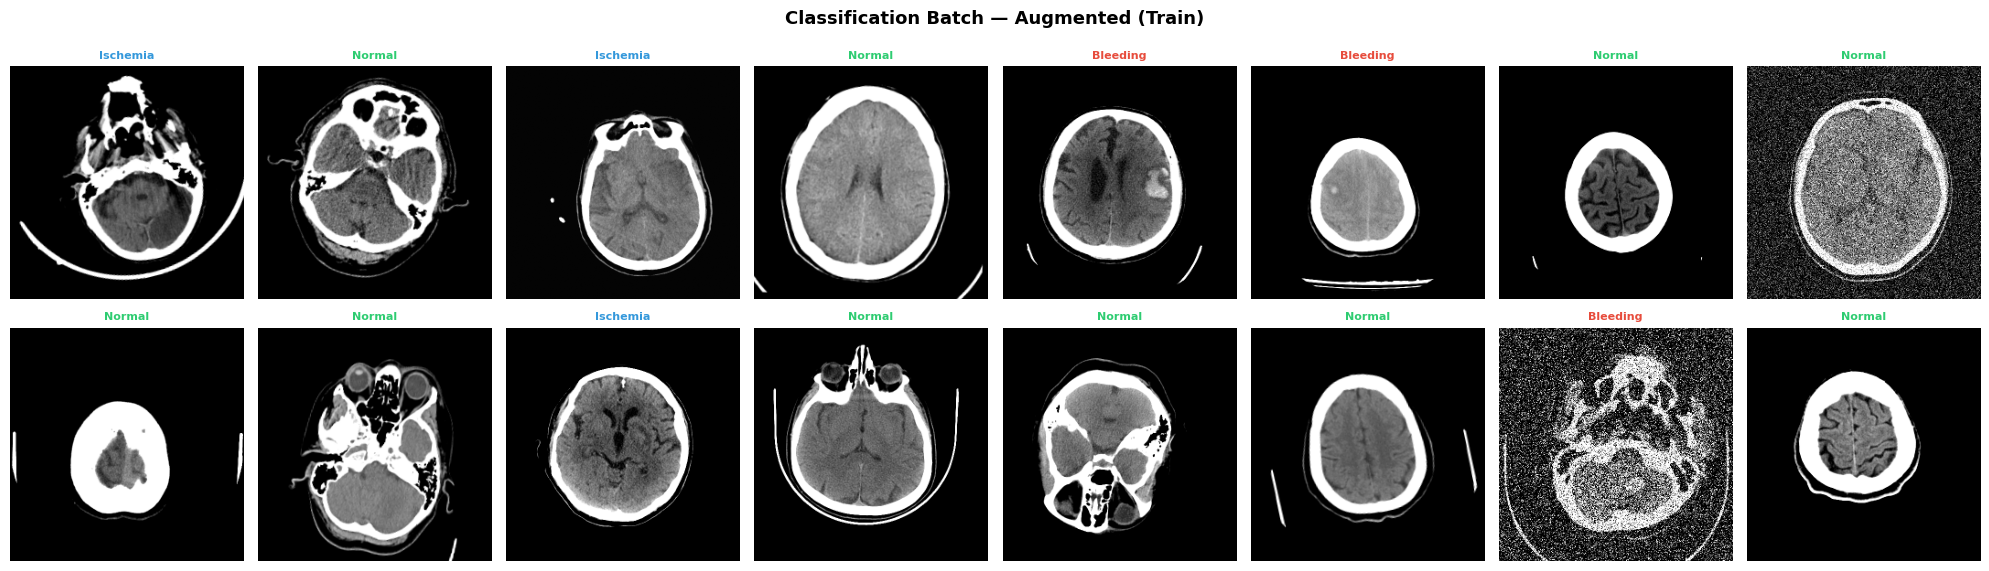

In [9]:
imgs, lbls = next(iter(clf_train_loader))
print(f'Classification batch — images: {imgs.shape}, labels: {lbls.shape}')
print(f'  Image range: [{imgs.min():.3f}, {imgs.max():.3f}]')
print(f'  Labels: {lbls.tolist()}')

cls_colors_hex = {'Bleeding': '#e74c3c', 'Ischemia': '#3498db', 'Normal': '#2ecc71'}

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle('Classification Batch — Augmented (Train)', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, (img, lbl) in enumerate(zip(imgs[:16], lbls[:16])):
    cls_name = IDX_TO_CLASS[lbl.item()]
    axes[i].imshow(img.squeeze().numpy(), cmap='gray')
    axes[i].set_title(cls_name, fontsize=8, color=cls_colors_hex[cls_name], fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(SAVE_DIR / 'clf_batch_sample.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Verify — Segmentation Batch

Segmentation batch — images: torch.Size([16, 1, 256, 256]), masks: torch.Size([16, 256, 256])
  Mask unique values: [0, 1]
  Positive pixels (lesion) in batch: 252558 / 1048576
  Samples with lesion in this batch: 4/16


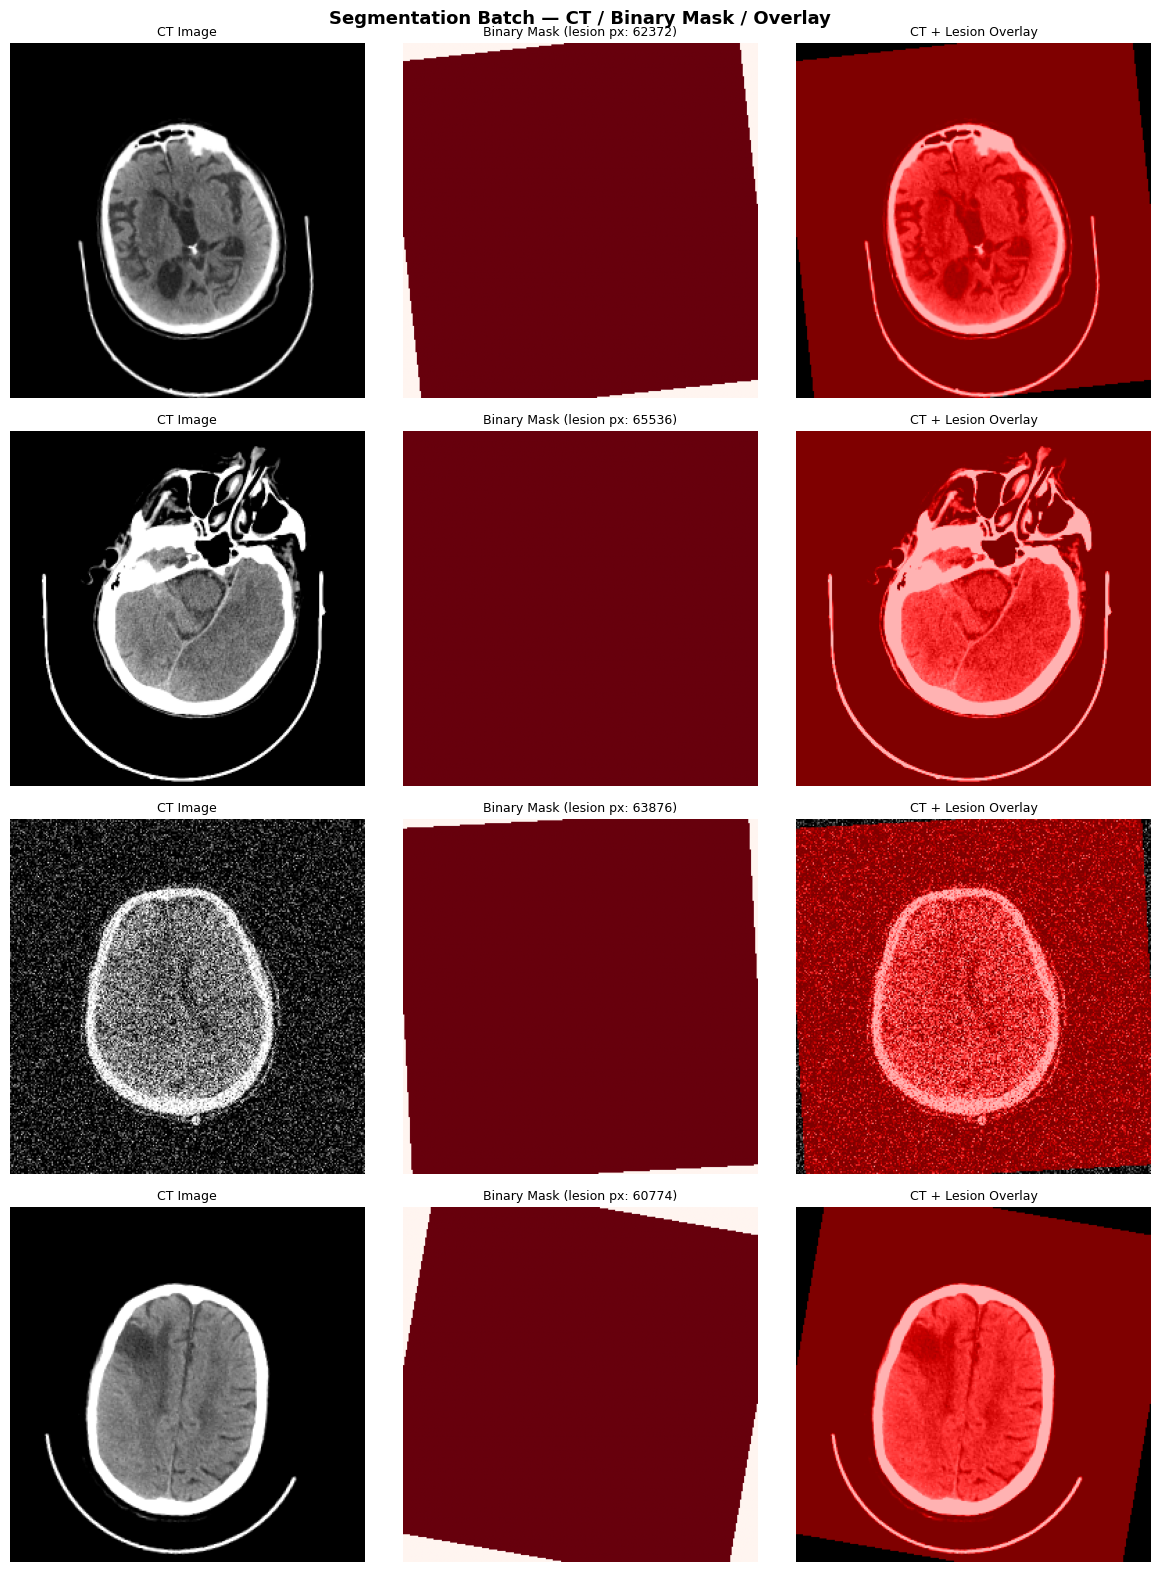

In [10]:
imgs, masks = next(iter(seg_train_loader))
print(f'Segmentation batch — images: {imgs.shape}, masks: {masks.shape}')
print(f'  Mask unique values: {masks.unique().tolist()}')
print(f'  Positive pixels (lesion) in batch: {masks.sum().item()} / {masks.numel()}')

# Find samples that actually have lesion pixels
has_lesion = [(i, m.sum().item()) for i, m in enumerate(masks) if m.sum() > 0]
print(f'  Samples with lesion in this batch: {len(has_lesion)}/{len(masks)}')

# Plot: CT | Mask | Overlay
n_show = min(4, len(has_lesion)) if has_lesion else 4
show_idx = [h[0] for h in has_lesion[:n_show]] if has_lesion else list(range(n_show))

fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show))
fig.suptitle('Segmentation Batch — CT / Binary Mask / Overlay', fontsize=13, fontweight='bold')

if n_show == 1:
    axes = [axes]

for row, idx in enumerate(show_idx):
    img  = imgs[idx].squeeze().numpy()
    mask = masks[idx].numpy()

    axes[row][0].imshow(img, cmap='gray')
    axes[row][0].set_title('CT Image', fontsize=9)
    axes[row][0].axis('off')

    axes[row][1].imshow(mask, cmap='Reds', vmin=0, vmax=1)
    axes[row][1].set_title(f'Binary Mask (lesion px: {mask.sum()})', fontsize=9)
    axes[row][1].axis('off')

    # Overlay: red lesion on CT
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
    rgb = np.stack([img_norm] * 3, axis=-1)
    rgb[:, :, 0] = np.clip(rgb[:, :, 0] + mask * 0.5, 0, 1)
    rgb[:, :, 1] = np.clip(rgb[:, :, 1] - mask * 0.3, 0, 1)
    rgb[:, :, 2] = np.clip(rgb[:, :, 2] - mask * 0.3, 0, 1)

    axes[row][2].imshow(rgb)
    axes[row][2].set_title('CT + Lesion Overlay', fontsize=9)
    axes[row][2].axis('off')

plt.tight_layout()
plt.savefig(SAVE_DIR / 'seg_batch_sample.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Lesion Coverage Statistics

Lesion coverage in segmentation training set (sample of 200)...


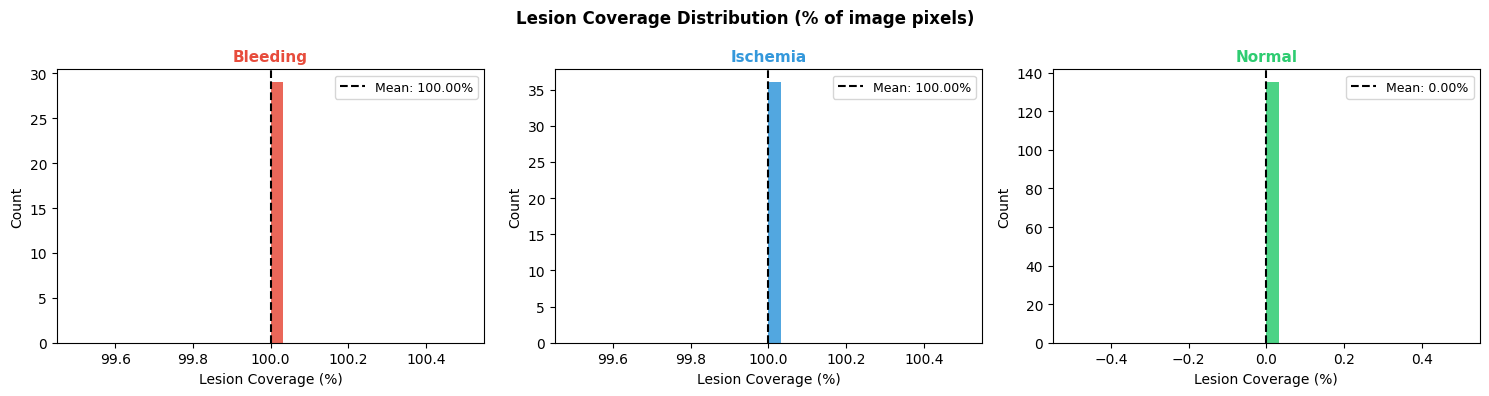

Bleeding    : mean=100.00%, max=100.00%, zero_masks=0/29
Ischemia    : mean=100.00%, max=100.00%, zero_masks=0/36
Normal      : mean=0.00%, max=0.00%, zero_masks=135/135


In [11]:
print('Lesion coverage in segmentation training set (sample of 200)...')
lesion_ratios = {'Bleeding': [], 'Ischemia': [], 'Normal': []}

# Sample up to 200 items for speed
check_samples = train_samples[:200]
for png_path, ovl_path, lbl in check_samples:
    mask = load_binary_mask(ovl_path)
    if mask is None:
        ratio = 0.0
    else:
        ratio = mask.sum() / mask.size
    lesion_ratios[IDX_TO_CLASS[lbl]].append(ratio)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Lesion Coverage Distribution (% of image pixels)', fontsize=12, fontweight='bold')

cls_colors_list = ['#e74c3c', '#3498db', '#2ecc71']
for ax, (cls, ratios), color in zip(axes, lesion_ratios.items(), cls_colors_list):
    ratios_pct = [r * 100 for r in ratios]
    ax.hist(ratios_pct, bins=30, color=color, alpha=0.85, edgecolor='none')
    ax.set_title(cls, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Lesion Coverage (%)')
    ax.set_ylabel('Count')
    if ratios_pct:
        ax.axvline(np.mean(ratios_pct), color='black', linestyle='--',
                   label=f'Mean: {np.mean(ratios_pct):.2f}%')
        ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'lesion_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

for cls, ratios in lesion_ratios.items():
    if ratios:
        pct = [r*100 for r in ratios]
        print(f'{cls:<12}: mean={np.mean(pct):.2f}%, max={np.max(pct):.2f}%, '
              f'zero_masks={sum(1 for r in ratios if r==0)}/{len(ratios)}')

## 11. Export Loaders for Training Notebooks

In [12]:
# All objects needed by training notebooks are defined above.
# In subsequent notebooks, run this cell to re-import everything:
#
#   %run 02_dataloaders.ipynb
#
# Or copy-paste the Dataset classes and use them directly.

print("Ready for training!")
print()
print("Classification:")
print(f"  clf_train_loader : {len(clf_train_loader)} batches x {BATCH_SIZE}")
print(f"  clf_val_loader   : {len(clf_val_loader)} batches")
print(f"  clf_test_loader  : {len(clf_test_loader)} batches")
print(f"  ext_clf_loader   : {len(ext_clf_loader)} batches (External_Test binary)")
print(f"  class_weights    : {class_weights.tolist()}")
print()
print("Segmentation:")
print(f"  seg_train_loader : {len(seg_train_loader)} batches x {BATCH_SIZE}")
print(f"  seg_val_loader   : {len(seg_val_loader)} batches")
print(f"  seg_test_loader  : {len(seg_test_loader)} batches")
print(f"  seg_ext_loader   : {len(seg_ext_loader)} batches (External_Test)")


Ready for training!

Classification:
  clf_train_loader : 312 batches x 16
  clf_val_loader   : 63 batches
  clf_test_loader  : 42 batches
  ext_clf_loader   : 13 batches (External_Test binary)
  class_weights    : [2.027235746383667, 1.9626131057739258, 0.5007027983665466]

Segmentation:
  seg_train_loader : 312 batches x 16
  seg_val_loader   : 63 batches
  seg_test_loader  : 42 batches
  seg_ext_loader   : 13 batches (External_Test)
